In [1]:
# ==========================
# Import Required Libraries
# ==========================

import os
import shutil
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================
# Visualization Settings
# ==========================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# ==========================
# Fix Random Seed
# ==========================

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv('/kaggle/input/datasets/abdoheshamelsayed/my-eye-data/metadata.csv')
# Display first 5 rows
df.head()

,filename,dataset,unified_label,original_label
0,ACRIMA_Im001_ACRIMA.jpg,ACRIMA,Normal,Normal
1,ACRIMA_Im002_ACRIMA.jpg,ACRIMA,Normal,Normal
2,ACRIMA_Im003_ACRIMA.jpg,ACRIMA,Normal,Normal
3,ACRIMA_Im004_ACRIMA.jpg,ACRIMA,Normal,Normal
4,ACRIMA_Im005_ACRIMA.jpg,ACRIMA,Normal,Normal


In [2]:
# ==========================
# Black Boreders cropping Function
# ==========================
import cv2
import numpy as np

def crop_black_border(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    c = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(c)

    cropped = img[y:y+h, x:x+w]

    return cropped

In [3]:
# ==========================
# Dataset Information
# ==========================

print(df.shape)

print(df.columns)

print(df.info())

(11839, 4)
Index(['filename', 'dataset', 'unified_label', 'original_label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11839 entries, 0 to 11838
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   filename        11839 non-null  object
 1   dataset         11839 non-null  object
 2   unified_label   11839 non-null  object
 3   original_label  11839 non-null  object
dtypes: object(4)
memory usage: 370.1+ KB
None


In [4]:
# ==========================
# Available Disease Classes
# ==========================

print(df["unified_label"].unique())

# ==========================
# Source Datasets
# ==========================

print(df["dataset"].unique())

['Normal' 'Glaucoma' 'Diabetic Retinopathy' 'Cataract' 'Others' 'Myopia'
 'Hypertension' 'AMD']
['ACRIMA' 'APTOS2019' 'ORIGA' 'ODIR5K']


In [5]:
# ==========================
# Check Missing Values
# ==========================

print(df.isnull().sum())

filename          0
dataset           0
unified_label     0
original_label    0
dtype: int64


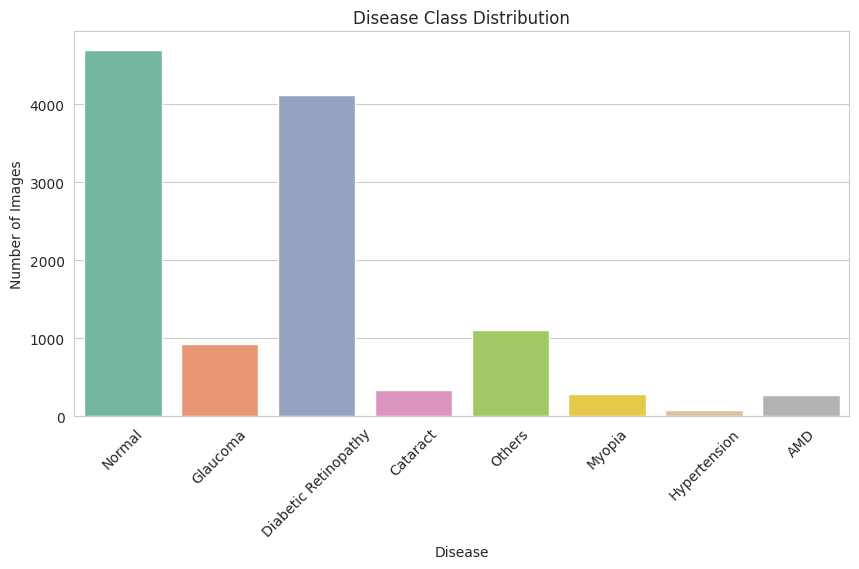

In [6]:
# ==========================
# Disease Class Distribution
# ==========================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="unified_label",
    hue="unified_label",
    palette="Set2",
    legend=False
)

plt.title("Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

In [7]:
import gdown

gdown.download(
    id="1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS",
    output="images.zip",
    quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS
From (redirected): https://drive.google.com/uc?id=1iUArOsSfS9lczQWAJx_xLGCvC6qhqzKS&confirm=t&uuid=bda694f6-a6d2-4dc0-bbe3-523b092e1b72
To: /kaggle/working/images.zip
100%|██████████| 4.08G/4.08G [00:39<00:00, 102MB/s] 


'images.zip'

In [8]:
import zipfile

EXTRACT_PATH = "/kaggle/working/images"

with zipfile.ZipFile("/kaggle/working/images.zip", "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Done")
print(os.listdir(EXTRACT_PATH)[:5])

Done
['catalog', 'Tasks_and_Classes.md', 'metadata.csv', 'images', 'splits']


In [9]:
IMAGE_FOLDER = "/kaggle/working/images/images"

df["image_path"] = df["filename"].apply(
    lambda x: os.path.join(IMAGE_FOLDER, x)
)

print(df["image_path"].iloc[0])

/kaggle/working/images/images/ACRIMA_Im001_ACRIMA.jpg


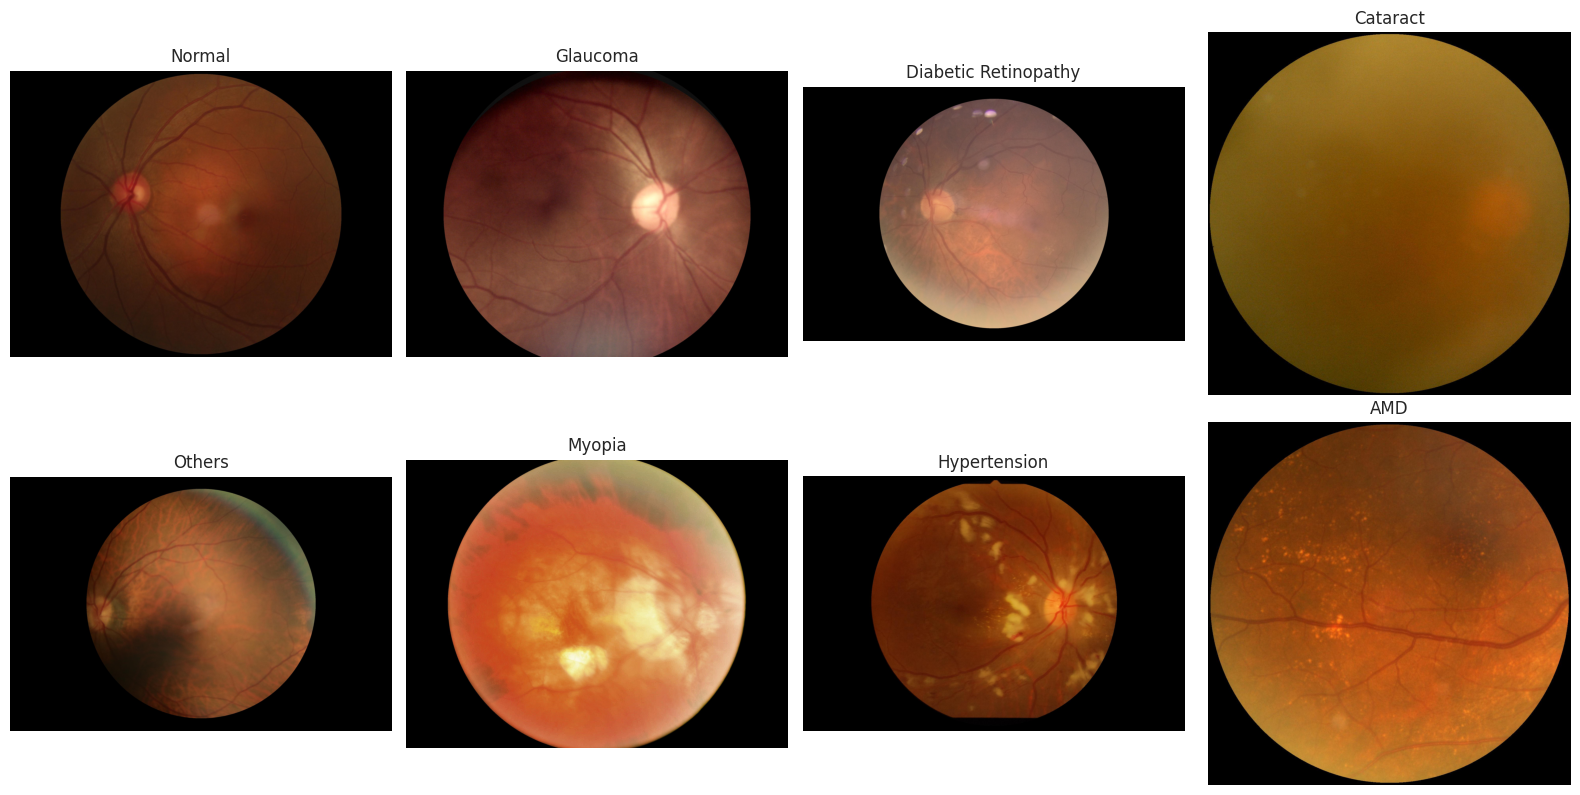

In [10]:
# ==========================
# Display One Image From Each Class
# ==========================

fig, axes = plt.subplots(2,4, figsize=(16,8))

classes = df["unified_label"].unique()

for ax, cls in zip(axes.flat, classes):

    sample = df[df["unified_label"] == cls].sample(1).iloc[0]

    image = Image.open(sample["image_path"])

    ax.imshow(image)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

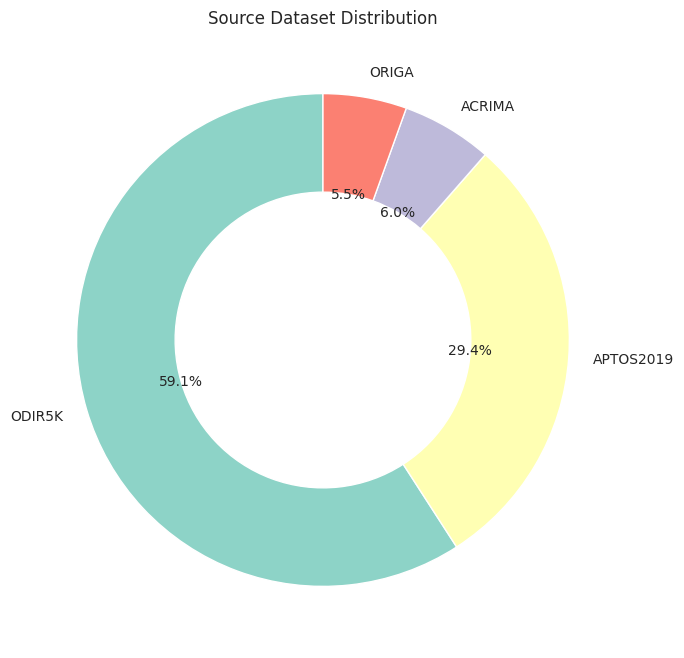

In [11]:
# ==========================
# Dataset Source Distribution
# ==========================

source_counts = df["dataset"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    source_counts,
    labels=source_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4},
    colors=plt.cm.Set3.colors
)

plt.title("Source Dataset Distribution")

plt.show()

In [12]:
# ==========================
# Number of Images Per Class
# ==========================

print(df["unified_label"].value_counts())

unified_label
Normal                  4698
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64


In [13]:
# ==========================================================
# Split Dataset
# ==========================================================

train_df, temp_df = train_test_split(df,test_size=0.20,stratify=df["unified_label"],random_state=42)

val_df, test_df = train_test_split(temp_df,test_size=0.50,stratify=temp_df["unified_label"],random_state=42)

In [14]:
# ==========================================================
# Number of Images in Each Split
# ==========================================================

print(f"Training Images   : {len(train_df)}")
print(f"Validation Images : {len(val_df)}")
print(f"Testing Images    : {len(test_df)}")

Training Images   : 9471
Validation Images : 1184
Testing Images    : 1184


In [15]:
# ==========================================================
# Check Class Distribution
# ==========================================================

print("Training Set")
print(train_df["unified_label"].value_counts())

print("\nValidation Set")
print(val_df["unified_label"].value_counts())

print("\nTesting Set")
print(test_df["unified_label"].value_counts())

Training Set
unified_label
Normal                  3758
Diabetic Retinopathy    3290
Others                   882
Glaucoma                 744
Cataract                 272
Myopia                   235
AMD                      219
Hypertension              71
Name: count, dtype: int64

Validation Set
unified_label
Normal                  470
Diabetic Retinopathy    412
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   30
AMD                      27
Hypertension              8
Name: count, dtype: int64

Testing Set
unified_label
Normal                  470
Diabetic Retinopathy    411
Others                  110
Glaucoma                 93
Cataract                 34
Myopia                   29
AMD                      28
Hypertension              9
Name: count, dtype: int64


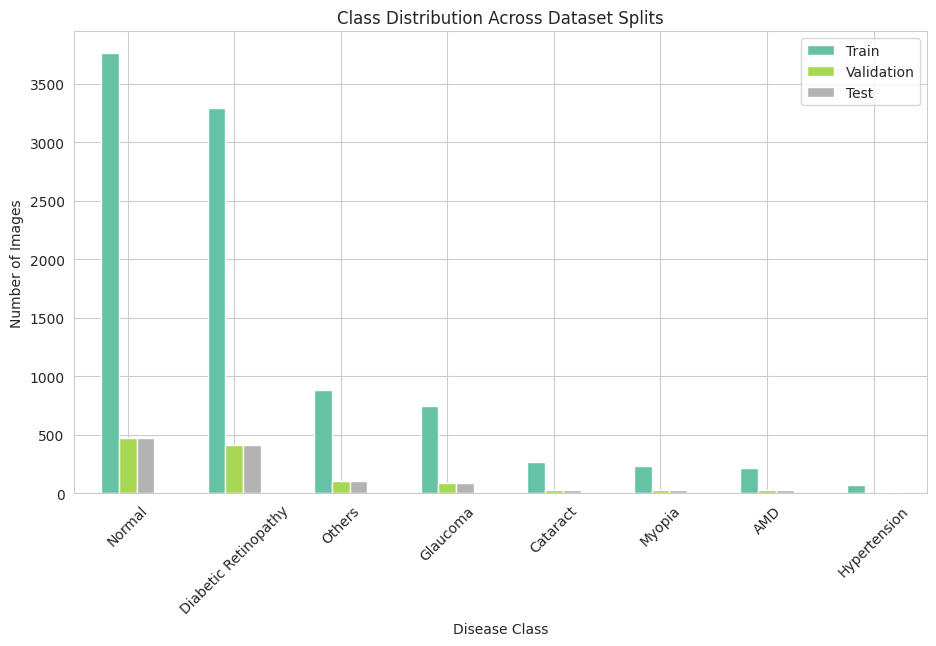

In [16]:
# ==========================================================
# Visualize Dataset Split
# ==========================================================

train_counts = train_df["unified_label"].value_counts()
val_counts = val_df["unified_label"].value_counts()
test_counts = test_df["unified_label"].value_counts()

plot_df = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
}).fillna(0)

plot_df.plot(
    kind="bar",
    figsize=(11,6),
    colormap="Set2"
)

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

In [17]:
# ==========================================================
# Create Dataset Folder Structure
# ==========================================================

classes = sorted(df["unified_label"].unique())

for split in ["train", "val", "test"]:

    for cls in classes:

        os.makedirs(
            os.path.join("dataset", split, cls),
            exist_ok=True
        )

In [18]:
# ==========================================================
# Copy Images Into Train / Validation / Test
# ==========================================================

SOURCE_FOLDER = IMAGE_FOLDER

def copy_images(dataframe, split):

    for _, row in dataframe.iterrows():

        source_path = row["image_path"]

        label = row["unified_label"]

        filename = row["filename"]

        destination = os.path.join(
            "dataset",
            split,
            label,
            filename
        )

        img = cv2.imread(source_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = crop_black_border(img)

        img = cv2.resize(img,(256,256))

        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        cv2.imwrite(destination, img)

copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

print("Images copied successfully.")

Images copied successfully.


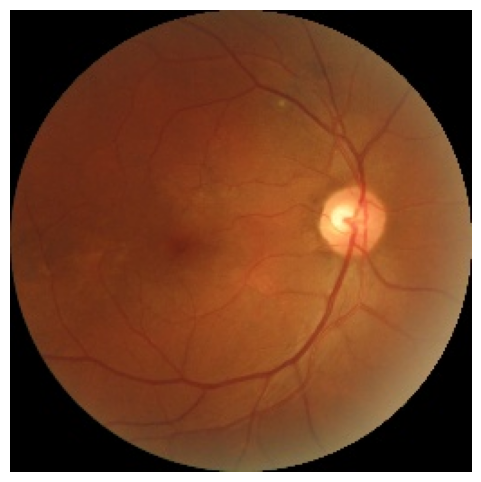

In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

sample_class = os.listdir("dataset/train")[0]

sample_img = random.choice(
    os.listdir(f"dataset/train/{sample_class}")
)

img = Image.open(
    f"dataset/train/{sample_class}/{sample_img}"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
# # ==========================================================
# # Augmentation for Minority Classes
# # ==========================================================

from tensorflow.keras.preprocessing.image import (ImageDataGenerator,load_img,img_to_array)

augmentor = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    shear_range=0.1,

    horizontal_flip=True,

    fill_mode="nearest"

)

target_counts = {

"Cataract":1500,
"Myopia":1500,
"AMD":1500,
"Hypertension":1500,
"Glaucoma":1500,
"Others":1500

}

In [21]:
# ==========================================================
# Oversample Minority Classes in Training Set Only
# ==========================================================

from tensorflow.keras.preprocessing.image import array_to_img

for cls, target in target_counts.items():

    class_dir = os.path.join("dataset", "train", cls)

    if not os.path.exists(class_dir):
        print(f"Skipping {cls}, folder not found.")
        continue

    current_images = os.listdir(class_dir)
    current_count = len(current_images)

    if current_count >= target:
        print(f"{cls}: {current_count} images, no oversampling needed.")
        continue

    needed = target - current_count
    print(f"{cls}: {current_count} -> {target} (generating {needed} images)")

    i = 0
    while i < needed:

        img_name = random.choice(current_images)
        img_path = os.path.join(class_dir, img_name)

        img = load_img(img_path)
        img_array = img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)

        for batch in augmentor.flow(img_array, batch_size=1):
            aug_img = array_to_img(batch[0])
            aug_img.save(os.path.join(class_dir, f"aug_{i}_{img_name}"))
            i += 1
            break

print("Oversampling done.")

Cataract: 272 -> 1500 (generating 1228 images)
Myopia: 235 -> 1500 (generating 1265 images)
AMD: 219 -> 1500 (generating 1281 images)
Hypertension: 71 -> 1500 (generating 1429 images)
Glaucoma: 744 -> 1500 (generating 756 images)
Others: 882 -> 1500 (generating 618 images)
Oversampling done.


In [22]:
# ==========================================================
# Verify Class Counts After Oversampling
# ==========================================================

for cls in sorted(os.listdir("dataset/train")):
    class_dir = os.path.join("dataset", "train", cls)
    count = len(os.listdir(class_dir))
    print(f"{cls}: {count}")

AMD: 1500
Cataract: 1500
Diabetic Retinopathy: 3290
Glaucoma: 1500
Hypertension: 1500
Myopia: 1500
Normal: 3758
Others: 1500


In [23]:
# ==========================================================
# Image Data Augmentation
# ==========================================================

train_datagen = ImageDataGenerator(

    rescale=1/255,

    rotation_range=20,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    shear_range=0.1,

    horizontal_flip=True,

    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1/255
)

test_datagen = ImageDataGenerator(
    rescale=1/255
)

In [24]:
# ==========================================================
# Create Image Generators
# ==========================================================

IMAGE_SIZE = (256,256)

BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(

    "dataset/train",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"

)

val_generator = val_datagen.flow_from_directory(

    "dataset/val",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"

)

test_generator = test_datagen.flow_from_directory(

    "dataset/test",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)

Found 16048 images belonging to 8 classes.
Found 1184 images belonging to 8 classes.
Found 1184 images belonging to 8 classes.


In [25]:
# ==========================================================
# Build CNN Model
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,BatchNormalization,GlobalAveragePooling2D,Dense,Dropout)

model = Sequential([

    Input(shape=(256,256,3)),

    # Block 1
    Conv2D(32,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(32,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(64,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(128,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(256,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 5
    Conv2D(512,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    Conv2D(512,(3,3),padding="same",activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(train_generator.num_classes, activation="softmax")


])

model.summary()

I0000 00:00:1783571726.550799      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,16

 Total params: 5,116,200 (19.52 MB)

 Trainable params: 5,112,232 (19.50 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [26]:
# ==========================================================
# Compile CNN Model
# ==========================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])



In [27]:
# ==========================================================
# Train CNN Model
# ==========================================================

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=30,

)


Epoch 1/30
  1/502 ━━━━━━━━━━━━━━━━━━━━ 3:42:25 27s/step - accuracy: 0.1875 - loss: 2.2778

I0000 00:00:1783571755.674190     153 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


502/502 ━━━━━━━━━━━━━━━━━━━━ 290s 525ms/step - accuracy: 0.4164 - loss: 1.5914 - val_accuracy: 0.2956 - val_loss: 1.8266
Epoch 2/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 244s 487ms/step - accuracy: 0.5312 - loss: 1.2520 - val_accuracy: 0.5676 - val_loss: 1.1148
Epoch 3/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 245s 488ms/step - accuracy: 0.5629 - loss: 1.1587 - val_accuracy: 0.5566 - val_loss: 1.1140
Epoch 4/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 245s 487ms/step - accuracy: 0.5907 - loss: 1.0882 - val_accuracy: 0.5718 - val_loss: 1.2003
Epoch 5/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 241s 480ms/step - accuracy: 0.6046 - loss: 1.0433 - val_accuracy: 0.5557 - val_loss: 1.2202
Epoch 6/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 242s 482ms/step - accuracy: 0.6198 - loss: 1.0039 - val_accuracy: 0.5220 - val_loss: 1.5271
Epoch 7/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 249s 495ms/step - accuracy: 0.6319 - loss: 0.9665 - val_accuracy: 0.5980 - val_loss: 1.0353
Epoch 8/30
502/502 ━━━━━━━━━━━━━━━━━━━━ 250s 497ms/step - accuracy: 0.6411 - loss: 0.94

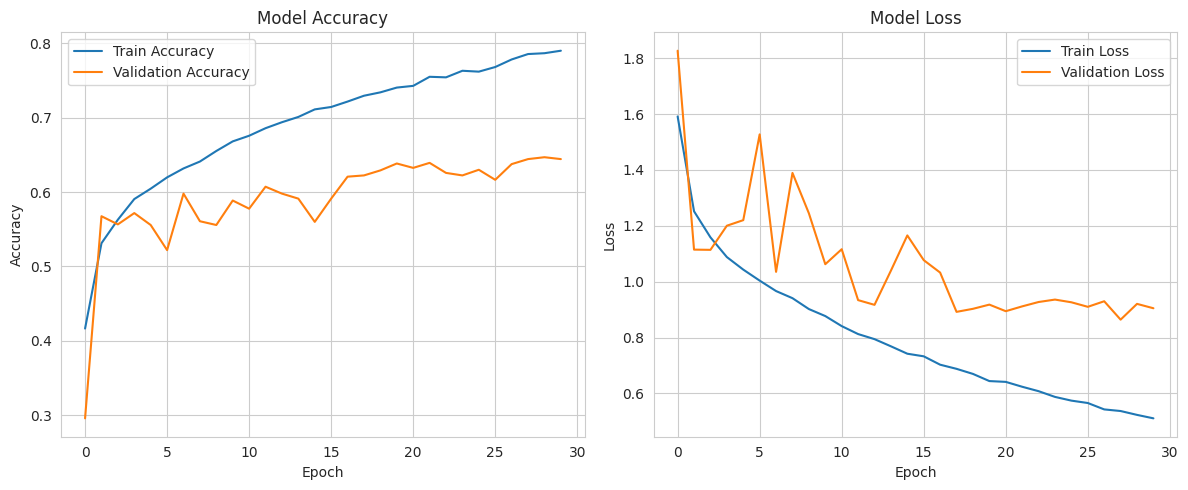

In [28]:
# ==========================================================
# Plot Accuracy & Loss
# ==========================================================

plt.figure(figsize=(12,5))

# Training Accuracy
plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Training Loss
plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
# ==========================================================
# Evaluate Model on Test Dataset
# ==========================================================

loss, accuracy = model.evaluate(test_generator)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6562 - loss: 0.9036

Test Loss     : 0.9036
Test Accuracy : 0.6562


In [30]:
# ==========================================================
# Get Predictions
# ==========================================================

predictions = model.predict(test_generator)

# Predicted class indices

y_pred = predictions.argmax(axis=1)

# True class indices

y_true = test_generator.classes

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step


In [31]:
# ==========================================================
# Convert Class Indices To Class Names
# ==========================================================

class_names = list(test_generator.class_indices.keys())

y_pred_labels = [class_names[i] for i in y_pred]

y_true_labels = [class_names[i] for i in y_true]

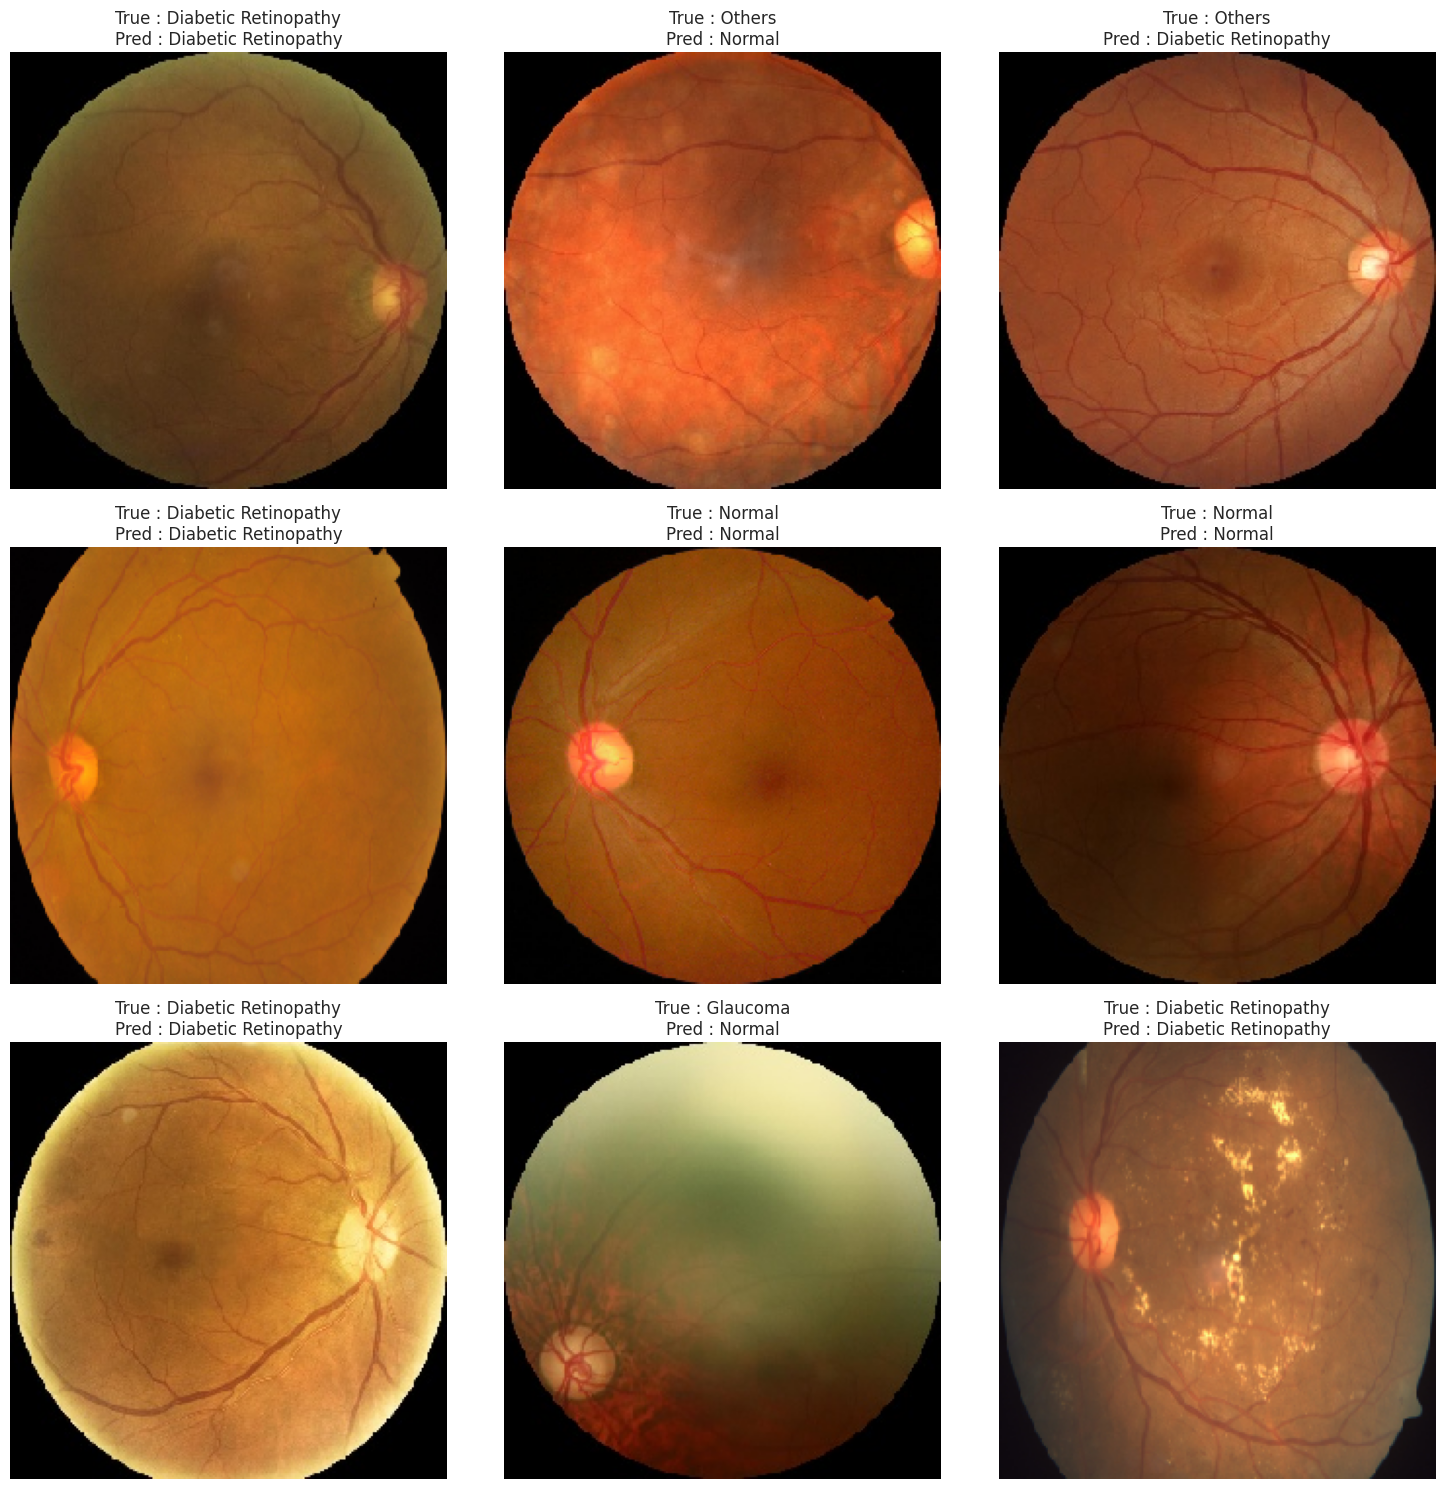

In [36]:
# ==========================================================
# Display Random Predictions
# ==========================================================

import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Select random images
filepaths = test_generator.filepaths
indices = random.sample(range(len(filepaths)), 9)

plt.figure(figsize=(15,15))

for i, idx in enumerate(indices):

    img = image.load_img(

        filepaths[idx],

        target_size=(224,224)

    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(

        f"True : {class_names[y_true[idx]]}\n"

        f"Pred : {class_names[y_pred[idx]]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [37]:
# ==========================================================
# Classification Report
# ==========================================================

class_names = list(train_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                      precision    recall  f1-score   support

                 AMD       0.25      0.04      0.06        28
            Cataract       0.62      0.68      0.65        34
Diabetic Retinopathy       0.60      0.84      0.70       411
            Glaucoma       0.67      0.63      0.65        93
        Hypertension       0.00      0.00      0.00         9
              Myopia       0.84      0.55      0.67        29
              Normal       0.73      0.71      0.72       470
              Others       0.00      0.00      0.00       110

            accuracy                           0.66      1184
           macro avg       0.46      0.43      0.43      1184
        weighted avg       0.59      0.66      0.62      1184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Pretrained Model

In [38]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (GlobalAveragePooling2D,Dense,Dropout)

from tensorflow.keras.optimizers import Adam



In [39]:
# ==========================================================
# Get Number of Classes
# ==========================================================

NUM_CLASSES = train_generator.num_classes

print(NUM_CLASSES)

8


In [40]:
# ==========================================================
# Load Pretrained EfficientNetB0
# ==========================================================

base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(256,256,3)

)

# Freeze all backbone layers

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
# ==========================================================
# Image Data Augmentation
# ==========================================================
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.2,

    shear_range=0.1,

    horizontal_flip=True,

    fill_mode="nearest"
)


val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [42]:
# ==========================================================
# Create Image Generators
# ==========================================================

IMAGE_SIZE = (256,256)

BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(

    "dataset/train",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"

)

val_generator = val_datagen.flow_from_directory(

    "dataset/val",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical"

)

test_generator = test_datagen.flow_from_directory(

    "dataset/test",

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 16048 images belonging to 8 classes.
Found 1184 images belonging to 8 classes.
Found 1184 images belonging to 8 classes.


In [43]:
# ==========================================================
# Build Classification Head
# ==========================================================

x = base_model.output

# Convert feature maps into feature vector

x = GlobalAveragePooling2D()(x)

# Fully connected layer
x = Dense(512,activation="relu")(x)

x = Dense(256,activation="relu")(x)

# Reduce overfitting

x = Dropout(0.4)(x)

# Output layer

outputs = Dense(NUM_CLASSES,activation="softmax")(x)

model_eff = Model(inputs=base_model.input,outputs=outputs)

In [45]:
# ==========================================================
# Compile Model
# ==========================================================

model_eff.compile(optimizer=Adam(learning_rate=1e-5),loss="categorical_crossentropy",metrics=["accuracy"])

In [46]:
# ==========================================================
# Feature Extraction Training
# ==========================================================

history = model_eff.fit(

    train_generator,

    validation_data=val_generator,

    epochs=20,

)

Epoch 1/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 285s 514ms/step - accuracy: 0.3227 - loss: 1.8367 - val_accuracy: 0.5414 - val_loss: 1.3502
Epoch 2/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 239s 477ms/step - accuracy: 0.4991 - loss: 1.4511 - val_accuracy: 0.5735 - val_loss: 1.1576
Epoch 3/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 240s 477ms/step - accuracy: 0.5424 - loss: 1.2738 - val_accuracy: 0.5946 - val_loss: 1.0958
Epoch 4/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 236s 470ms/step - accuracy: 0.5700 - loss: 1.1794 - val_accuracy: 0.6064 - val_loss: 1.0563
Epoch 5/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 239s 476ms/step - accuracy: 0.5918 - loss: 1.1197 - val_accuracy: 0.6149 - val_loss: 1.0377
Epoch 6/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 240s 478ms/step - accuracy: 0.6053 - loss: 1.0838 - val_accuracy: 0.6309 - val_loss: 1.0194
Epoch 7/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 237s 472ms/step - accuracy: 0.6171 - loss: 1.0506 - val_accuracy: 0.6368 - val_loss: 1.0198
Epoch 8/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 235s 469ms/step - accuracy: 0.6267 -

In [47]:
# ==========================================================
# Unfreeze EfficientNet Layers
# ==========================================================

base_model.trainable = True
# ==========================================================
# Freeze Early Layers
# ==========================================================

for layer in base_model.layers[:-30]:

    layer.trainable = False

In [48]:
# ==========================================================
# Recompile Model For Fine Tuning
# ==========================================================

model_eff.compile(optimizer=Adam(learning_rate=1e-5),loss="categorical_crossentropy",metrics=["accuracy"])

In [49]:
# ==========================================================
# Fine Tuning
# ==========================================================

history = model_eff.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

)

Epoch 1/15


2026-07-09 08:04:43.049176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 08:04:43.255793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 08:04:43.684755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 08:04:43.891205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 11/502 ━━━━━━━━━━━━━━━━━━━━ 3:30 429ms/step - accuracy: 0.5296 - loss: 1.4478

2026-07-09 08:05:04.544409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 08:05:04.751182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 08:05:05.143559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-09 08:05:05.348204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


502/502 ━━━━━━━━━━━━━━━━━━━━ 290s 514ms/step - accuracy: 0.6218 - loss: 1.1335 - val_accuracy: 0.6360 - val_loss: 0.9769
Epoch 2/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 235s 468ms/step - accuracy: 0.6536 - loss: 0.9706 - val_accuracy: 0.6495 - val_loss: 0.9366
Epoch 3/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 234s 466ms/step - accuracy: 0.6710 - loss: 0.9097 - val_accuracy: 0.6546 - val_loss: 0.9181
Epoch 4/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 236s 470ms/step - accuracy: 0.6796 - loss: 0.8754 - val_accuracy: 0.6630 - val_loss: 0.9061
Epoch 5/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 234s 466ms/step - accuracy: 0.6839 - loss: 0.8561 - val_accuracy: 0.6639 - val_loss: 0.8857
Epoch 6/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 234s 467ms/step - accuracy: 0.6965 - loss: 0.8242 - val_accuracy: 0.6622 - val_loss: 0.8803
Epoch 7/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 233s 463ms/step - accuracy: 0.7015 - loss: 0.8077 - val_accuracy: 0.6655 - val_loss: 0.8728
Epoch 8/15
502/502 ━━━━━━━━━━━━━━━━━━━━ 233s 463ms/step - accuracy: 0.7054 - loss: 0.79

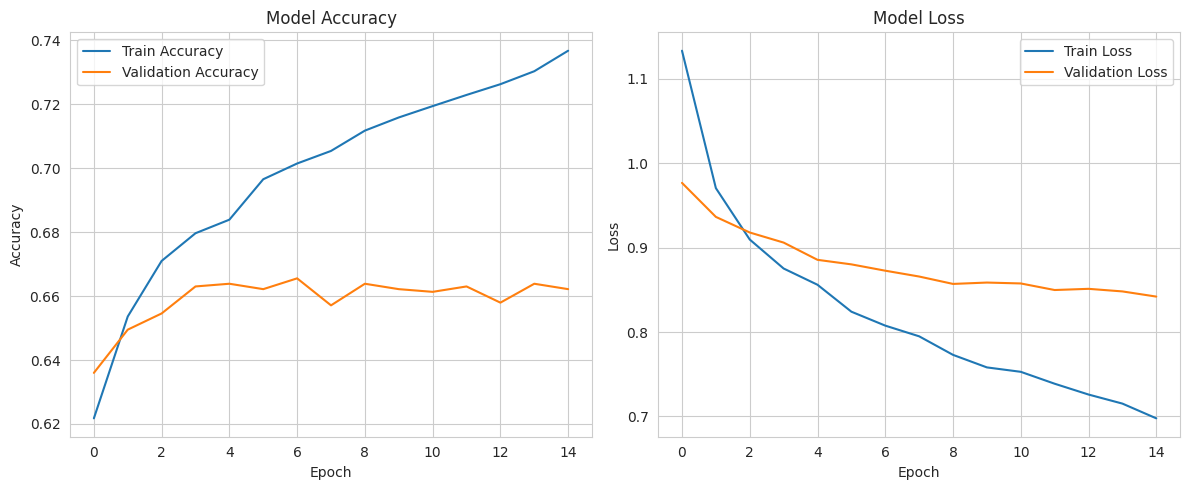

In [50]:
# ==========================================================
# Plot Accuracy & Loss
# ==========================================================

plt.figure(figsize=(12,5))

# Training Accuracy
plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Training Loss
plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# ==========================================================
# Evaluate Model
# ==========================================================

test_loss, test_acc = model_eff.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6596 - loss: 0.8433
Test Accuracy: 0.6596


In [52]:
# ==========================================================
# Get Predictions
# ==========================================================

predictions = model_eff.predict(test_generator)

# Predicted class indices

y_pred = predictions.argmax(axis=1)

# True class indices

y_true = test_generator.classes

37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step


In [53]:
# ==========================================================
# Convert Class Indices To Class Names
# ==========================================================

class_names = list(test_generator.class_indices.keys())

y_pred_labels = [class_names[i] for i in y_pred]

y_true_labels = [class_names[i] for i in y_true]

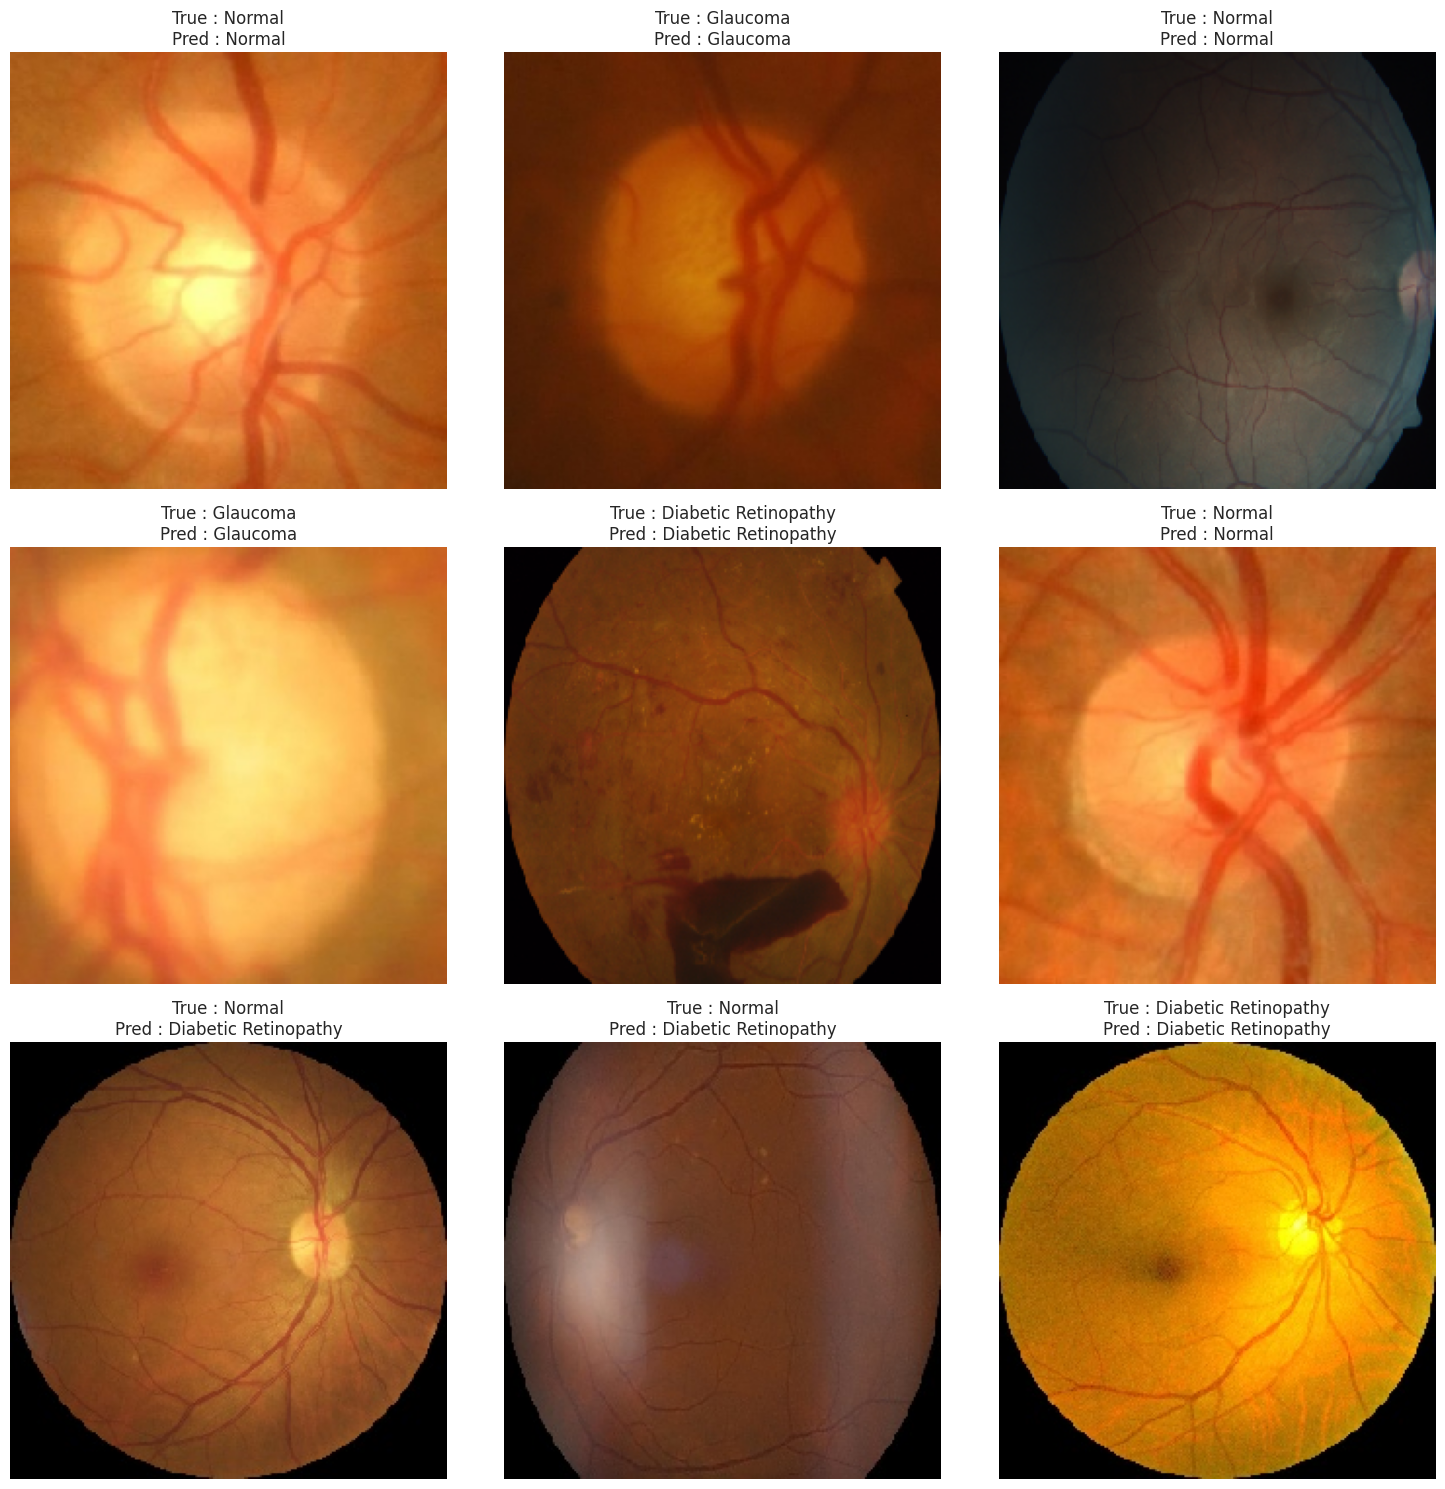

In [54]:
# ==========================================================
# Display Random Predictions
# ==========================================================

import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Select random images
filepaths = test_generator.filepaths
indices = random.sample(range(len(filepaths)), 9)

plt.figure(figsize=(15,15))

for i, idx in enumerate(indices):

    img = image.load_img(

        filepaths[idx],

        target_size=(224,224)

    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(

        f"True : {class_names[y_true[idx]]}\n"

        f"Pred : {class_names[y_pred[idx]]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [55]:
# ==========================================================
# Classification Report
# ==========================================================

class_names = list(train_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                      precision    recall  f1-score   support

                 AMD       0.33      0.04      0.06        28
            Cataract       0.66      0.62      0.64        34
Diabetic Retinopathy       0.62      0.83      0.71       411
            Glaucoma       0.81      0.47      0.60        93
        Hypertension       0.00      0.00      0.00         9
              Myopia       0.86      0.62      0.72        29
              Normal       0.68      0.76      0.72       470
              Others       0.00      0.00      0.00       110

            accuracy                           0.66      1184
           macro avg       0.50      0.42      0.43      1184
        weighted avg       0.60      0.66      0.62      1184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
